In [2]:
# Cell 1: Import libraries and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')
# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


In [4]:
# Cell 2: Load data
print("Loading data...")

# Load the CSV files
anime_df = pd.read_csv('../data/anime.csv')
anime_relations_df = pd.read_csv('../data/anime_anime.csv')
user_anime_df = pd.read_csv('../data/filtered_user_anime.csv')

print(f"Loaded:")
print(f"- {len(anime_df):,} anime entries")
print(f"- {len(anime_relations_df):,} anime relationships") 
print(f"- {len(user_anime_df):,} user-anime interactions")

# Quick data preview
print("\nAnime data columns:", anime_df.columns.tolist())
print("User-anime data columns:", user_anime_df.columns.tolist())
print("Relations data columns:", anime_relations_df.columns.tolist())

Loading data...
Loaded:
- 13,379 anime entries
- 214,271 anime relationships
- 181,526,955 user-anime interactions

Anime data columns: ['anime_id', 'anime_url', 'title', 'synopsis', 'main_pic', 'type', 'source_type', 'num_episodes', 'status', 'start_date', 'end_date', 'season', 'studios', 'genres', 'score', 'score_count', 'score_rank', 'popularity_rank', 'members_count', 'favorites_count', 'watching_count', 'completed_count', 'on_hold_count', 'dropped_count', 'plan_to_watch_count', 'total_count', 'score_10_count', 'score_09_count', 'score_08_count', 'score_07_count', 'score_06_count', 'score_05_count', 'score_04_count', 'score_03_count', 'score_02_count', 'score_01_count', 'clubs', 'pics']
User-anime data columns: ['anime_id', 'user_id', 'score', 'favorite']
Relations data columns: ['animeA', 'animeB', 'recommendation', 'recommendation_url', 'num_recommenders', 'related', 'relation_type']


In [7]:
print("Preprocessing data...")

# Clean anime data
anime_clean = anime_df.dropna(subset=['anime_id']).copy()

# Process genres - split multiple genres
anime_clean['genres_list'] = anime_clean['genres'].fillna('Unknown').apply(
    lambda x: x.split('|') if isinstance(x, str) else ['Unknown']
)

# Clean user ratings - only ratings with scores (no status column in this dataset)
user_anime_clean = user_anime_df[user_anime_df['score'].notna()].copy()

# Filter to only related anime pairs
related_anime = anime_relations_df[anime_relations_df['related'] == 1].copy()

print(f"After cleaning:")
print(f"- {len(user_anime_clean):,} user ratings with scores")
print(f"- {len(related_anime):,} related anime pairs")
print(f"- Relation types: {related_anime['relation_type'].unique()}")

Preprocessing data...
After cleaning:
- 110,274,397 user ratings with scores
- 128,658 related anime pairs
- Relation types: ['Other' 'Sequel' 'Prequel' 'Summary' 'Identity' 'Spin-off' 'Character'
 'Full story' 'Side story' 'Parent story' 'Alternative setting'
 'Alternative version']


=== ANALYSIS 1: General Rating Correlation Between Anime ===
Creating user-anime rating matrix...
Working with 100,000 users and 2,000 anime
Created matrix: 100000 users × 2000 anime
Calculating anime-anime correlations...
Filtered to 2000 anime with at least 50 ratings each
Computing pairwise correlations...

General Anime Rating Correlations:
Mean correlation: 0.0882
Std deviation: 0.0637
Number of anime pairs: 1,999,000


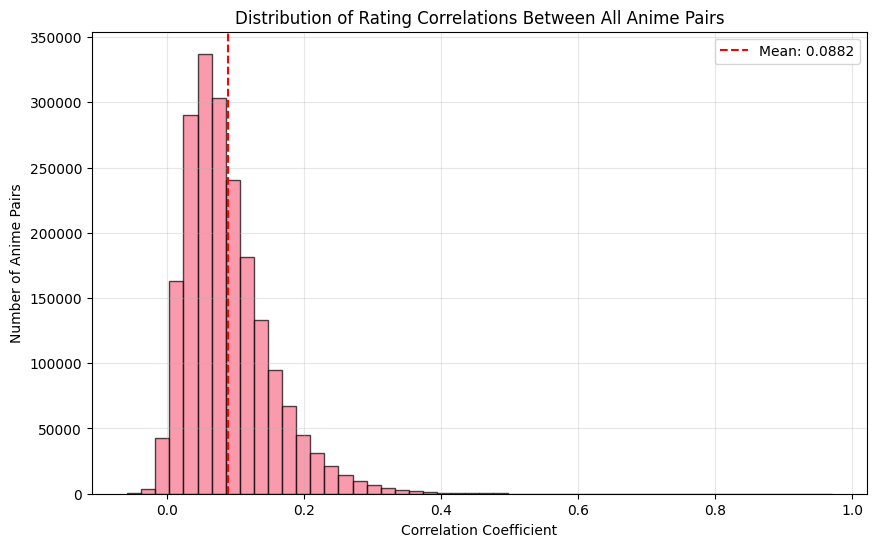

Correlations range from -0.0587 to 0.9699


In [11]:
# Cell 4: Analysis 1 - General Rating Correlation Between Anime
print("=== ANALYSIS 1: General Rating Correlation Between Anime ===")

# Create a user-anime matrix for correlation analysis
print("Creating user-anime rating matrix...")

# Sample users to make this computationally feasible (optional)
n_users_sample = 100000  # Adjust based on your computational capacity
user_sample = user_anime_clean['user_id'].unique()[:n_users_sample]
user_data_sample = user_anime_clean[user_anime_clean['user_id'].isin(user_sample)]

print(f"Working with {len(user_sample):,} users and {user_data_sample['anime_id'].nunique():,} anime")

# Create pivot table (users as rows, anime as columns, scores as values)
user_anime_matrix = user_data_sample.pivot_table(
    index='user_id', 
    columns='anime_id', 
    values='score'
).fillna(0)  # Fill NaN with 0 (no rating)

print(f"Created matrix: {user_anime_matrix.shape[0]} users × {user_anime_matrix.shape[1]} anime")

# Calculate correlation between anime (columns)
print("Calculating anime-anime correlations...")

# Only keep anime with sufficient ratings
min_ratings = 50  # Minimum number of ratings per anime
anime_rating_counts = (user_anime_matrix > 0).sum(axis=0)
popular_anime = anime_rating_counts[anime_rating_counts >= min_ratings].index

# Filter matrix to only popular anime
matrix_filtered = user_anime_matrix[popular_anime]
print(f"Filtered to {len(popular_anime)} anime with at least {min_ratings} ratings each")

# Calculate correlations between all anime pairs (this might take a while!)
print("Computing pairwise correlations...")
anime_correlations = matrix_filtered.corr()

# Get correlation values (excluding diagonal)
mask = np.triu(np.ones_like(anime_correlations), k=1).astype(bool)
correlation_values = anime_correlations.values[mask]

# Remove NaN values
correlation_values = correlation_values[~np.isnan(correlation_values)]

general_correlation_mean = np.mean(correlation_values)
general_correlation_std = np.std(correlation_values)

print(f"\nGeneral Anime Rating Correlations:")
print(f"Mean correlation: {general_correlation_mean:.4f}")
print(f"Std deviation: {general_correlation_std:.4f}")
print(f"Number of anime pairs: {len(correlation_values):,}")

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(correlation_values, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(general_correlation_mean, color='red', linestyle='--', 
           label=f'Mean: {general_correlation_mean:.4f}')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Number of Anime Pairs')
plt.title('Distribution of Rating Correlations Between All Anime Pairs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Correlations range from {np.min(correlation_values):.4f} to {np.max(correlation_values):.4f}")


=== ANALYSIS 2: Related Anime Rating Correlation ===
Analyzing correlations for related anime pairs...
Found 10583 related anime pairs in our dataset

Calculated correlations for 10583 related anime pairs

Related Anime Rating Correlations:
Mean correlation: 0.6345
Std deviation: 0.2346

Correlation by relationship type:
Other          : 0.3823 (n=894 pairs)
Sequel         : 0.7088 (n=937 pairs)
Prequel        : 0.7090 (n=929 pairs)
Identity       : 1.0000 (n=2000 pairs)
Spin-off       : 0.4622 (n=204 pairs)
Character      : 0.3759 (n=368 pairs)
Full story     : 0.5575 (n=114 pairs)
Side story     : 0.5303 (n=1109 pairs)
Parent story   : 0.5572 (n=3114 pairs)
Alternative setting: 0.4414 (n=431 pairs)
Alternative version: 0.4886 (n=435 pairs)
Summary        : 0.5856 (n=48 pairs)

COMPARISON:
General anime correlation:  0.0882 ± 0.0637
Related anime correlation:  0.6345 ± 0.2346
Difference (related - general): 0.5463
✓ Related anime show HIGHER correlation than general anime pairs!


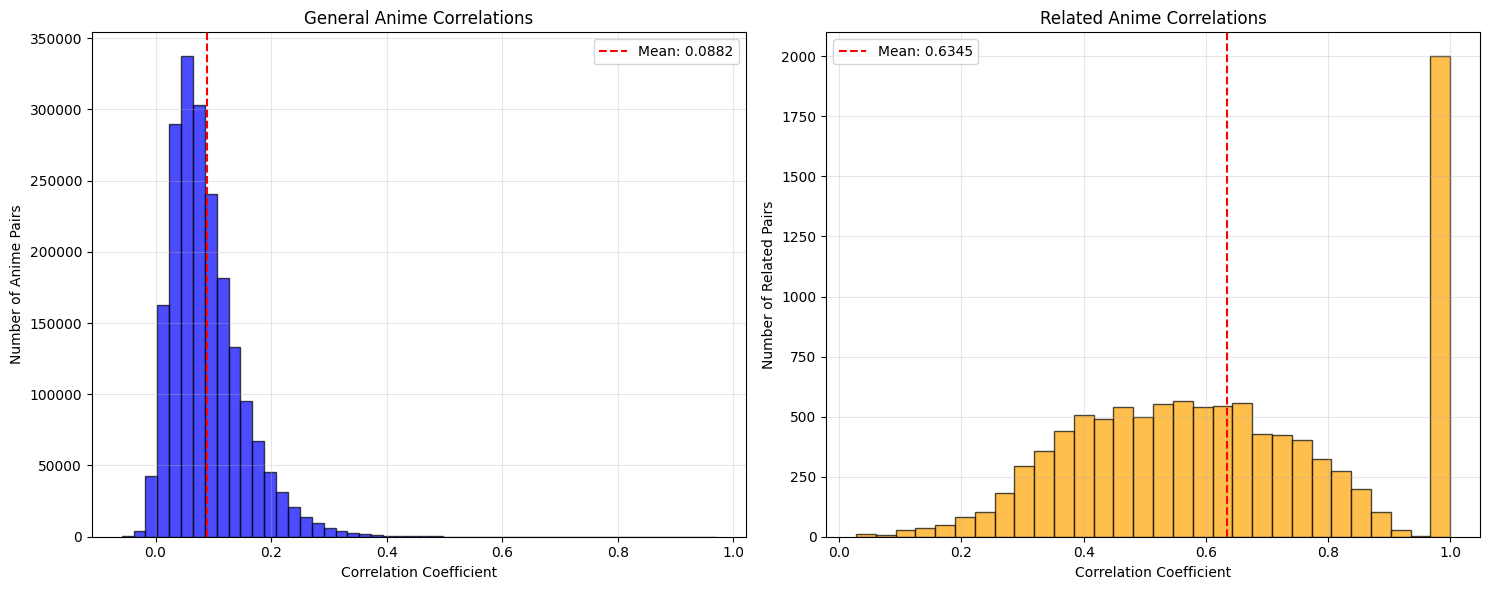


Statistical Test (t-test):
t-statistic: 456.9391
p-value: 0.0000
✓ The difference is statistically significant (p < 0.05)


In [12]:
# Cell 5: Analysis 2 - Related Anime Rating Correlation
print("=== ANALYSIS 2: Related Anime Rating Correlation ===")

# Use the same user-anime matrix from Cell 4
print("Analyzing correlations for related anime pairs...")

# Get related pairs that exist in our filtered matrix
related_pairs = []
available_anime = set(matrix_filtered.columns)

for _, row in related_anime.iterrows():
    anime_a, anime_b = row['animeA'], row['animeB']
    relation_type = row['relation_type']
    
    if anime_a in available_anime and anime_b in available_anime:
        related_pairs.append({
            'anime_a': anime_a,
            'anime_b': anime_b, 
            'relation_type': relation_type
        })

print(f"Found {len(related_pairs)} related anime pairs in our dataset")

# Calculate correlations for related pairs
related_correlations = []
relation_type_correlations = {}

for pair in related_pairs:
    anime_a, anime_b = pair['anime_a'], pair['anime_b']
    relation_type = pair['relation_type']
    
    # Get rating vectors for both anime
    ratings_a = matrix_filtered[anime_a]
    ratings_b = matrix_filtered[anime_b]
    
    # Only correlate where both anime have ratings (non-zero)
    both_rated = (ratings_a > 0) & (ratings_b > 0)
    
    if both_rated.sum() > 10:  # Need at least 10 common raters
        corr = np.corrcoef(ratings_a[both_rated], ratings_b[both_rated])[0, 1]
        
        if not np.isnan(corr):
            related_correlations.append(corr)
            
            if relation_type not in relation_type_correlations:
                relation_type_correlations[relation_type] = []
            relation_type_correlations[relation_type].append(corr)

print(f"\nCalculated correlations for {len(related_correlations)} related anime pairs")

# Summary statistics for related anime
related_correlation_mean = np.mean(related_correlations)
related_correlation_std = np.std(related_correlations)

print(f"\nRelated Anime Rating Correlations:")
print(f"Mean correlation: {related_correlation_mean:.4f}")
print(f"Std deviation: {related_correlation_std:.4f}")

# Break down by relationship type
print(f"\nCorrelation by relationship type:")
for rel_type, corrs in relation_type_correlations.items():
    if len(corrs) >= 3:  # Only show types with sufficient data
        mean_corr = np.mean(corrs)
        print(f"{rel_type:15s}: {mean_corr:.4f} (n={len(corrs)} pairs)")

# Compare to general correlations
print(f"\n" + "="*50)
print(f"COMPARISON:")
print(f"General anime correlation:  {general_correlation_mean:.4f} ± {general_correlation_std:.4f}")
print(f"Related anime correlation:  {related_correlation_mean:.4f} ± {related_correlation_std:.4f}")

difference = related_correlation_mean - general_correlation_mean
print(f"Difference (related - general): {difference:.4f}")

if difference > 0:
    print("✓ Related anime show HIGHER correlation than general anime pairs!")
else:
    print("✗ Related anime show LOWER correlation than general anime pairs")

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# General correlations
ax1.hist(correlation_values, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(general_correlation_mean, color='red', linestyle='--', 
           label=f'Mean: {general_correlation_mean:.4f}')
ax1.set_xlabel('Correlation Coefficient')
ax1.set_ylabel('Number of Anime Pairs')
ax1.set_title('General Anime Correlations')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Related anime correlations  
ax2.hist(related_correlations, bins=30, alpha=0.7, color='orange', edgecolor='black')
ax2.axvline(related_correlation_mean, color='red', linestyle='--',
           label=f'Mean: {related_correlation_mean:.4f}')
ax2.set_xlabel('Correlation Coefficient')
ax2.set_ylabel('Number of Related Pairs')
ax2.set_title('Related Anime Correlations')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical test to see if the difference is significant
from scipy.stats import ttest_ind

# Sample general correlations to match size if needed
if len(correlation_values) > len(related_correlations) * 10:
    general_sample = np.random.choice(correlation_values, 
                                     size=len(related_correlations)*5, 
                                     replace=False)
else:
    general_sample = correlation_values

t_stat, p_value = ttest_ind(related_correlations, general_sample)

print(f"\nStatistical Test (t-test):")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✓ The difference is statistically significant (p < 0.05)")
else:
    print("✗ The difference is not statistically significant (p >= 0.05)")

=== ANALYSIS 3: Score Distribution by Genre ===
Working with 10714 anime that have official scores
Created 33373 genre-score pairs

Analyzing 15 genres with 20+ anime:
genre
Comedy           4165
Action           3123
Fantasy          2294
Adventure        1993
Drama            1926
Sci-Fi           1868
Romance          1649
Shounen          1587
School           1414
Slice of Life    1332
Supernatural     1280
Mecha             742
Seinen            709
Historical        709
Ecchi             661
Name: count, dtype: int64


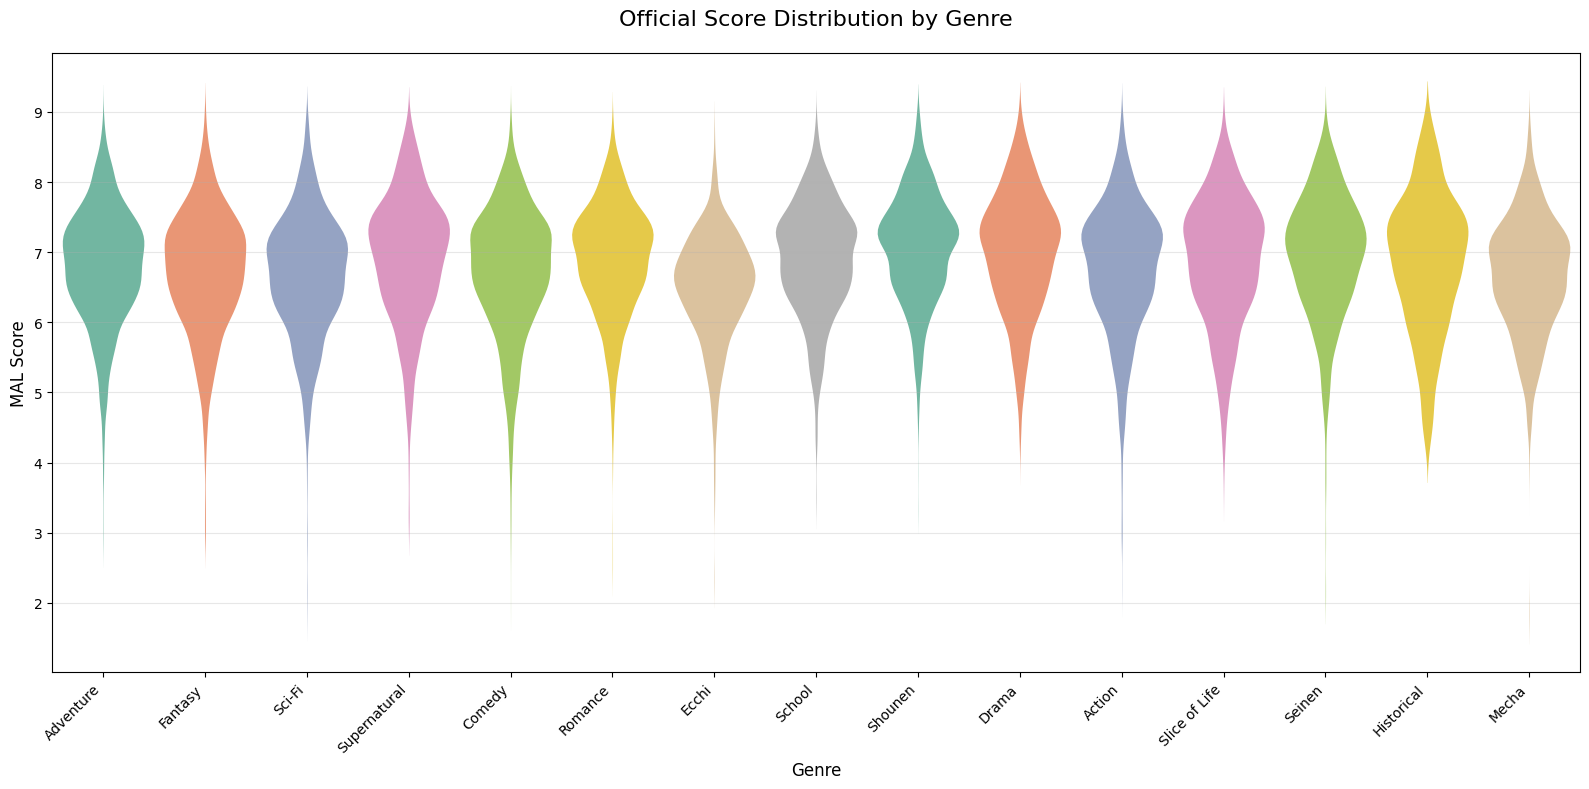


Genre Statistics (sorted by mean score):
                mean    std  count
genre                             
Shounen        7.083  0.765   1587
Drama          7.016  0.851   1926
Seinen         6.955  0.869    709
Supernatural   6.927  0.898   1280
School         6.900  0.793   1414
Romance        6.898  0.795   1649
Slice of Life  6.868  0.900   1332
Historical     6.853  0.971    709
Adventure      6.802  0.825   1993
Action         6.777  0.914   3123
Fantasy        6.721  0.868   2294
Comedy         6.707  0.917   4165
Mecha          6.670  0.814    742
Sci-Fi         6.670  0.879   1868
Ecchi          6.493  0.764    661


In [18]:
# Cell 6: Analysis 3 - Score Distribution by Genre
print("=== ANALYSIS 3: Score Distribution by Genre ===")

# Use anime.csv directly - much simpler!
anime_with_scores = anime_clean[anime_clean['score'].notna()].copy()
print(f"Working with {len(anime_with_scores)} anime that have official scores")

# Create genre-score mapping
genre_scores = []
for _, row in anime_with_scores.iterrows():
    score = row['score']
    genres = row['genres_list']
    
    for genre in genres:
        if genre and genre != 'Unknown' and genre.strip().lower() != 'hentai':  # Skip empty/unknown/hentai genres
            genre_scores.append({'genre': genre.strip(), 'score': score})

genre_df = pd.DataFrame(genre_scores)
print(f"Created {len(genre_df)} genre-score pairs")

# Filter to genres with sufficient data
genre_counts = genre_df['genre'].value_counts()
min_anime_per_genre = 20  # Minimum anime per genre
popular_genres = genre_counts[genre_counts >= min_anime_per_genre].index[:15]  # Top 15 genres

genre_df_filtered = genre_df[genre_df['genre'].isin(popular_genres)]

print(f"\nAnalyzing {len(popular_genres)} genres with {min_anime_per_genre}+ anime:")
print(genre_counts[popular_genres].sort_values(ascending=False))

# Create the distribution plot
plt.figure(figsize=(16, 8))

# Streamlined violin plot with colors
sns.violinplot(data=genre_df_filtered, x='genre', y='score', 
               palette='Set2', linewidth=0)  # Remove borders with linewidth=0
plt.xticks(rotation=45, ha='right')
plt.title('Official Score Distribution by Genre', fontsize=16, pad=20)
plt.ylabel('MAL Score', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')  # Add subtle horizontal grid lines
plt.tight_layout()
plt.show()

# Summary statistics by genre
genre_stats = genre_df_filtered.groupby('genre')['score'].agg(['mean', 'std', 'count']).round(3)
genre_stats = genre_stats.sort_values('mean', ascending=False)
print("\nGenre Statistics (sorted by mean score):")
print(genre_stats)

=== ANALYSIS 4: Genre Similarity Statistical Tests ===
Performing pairwise Kolmogorov-Smirnov tests...
Comparing 15 genres with 25452 total genre-score pairs


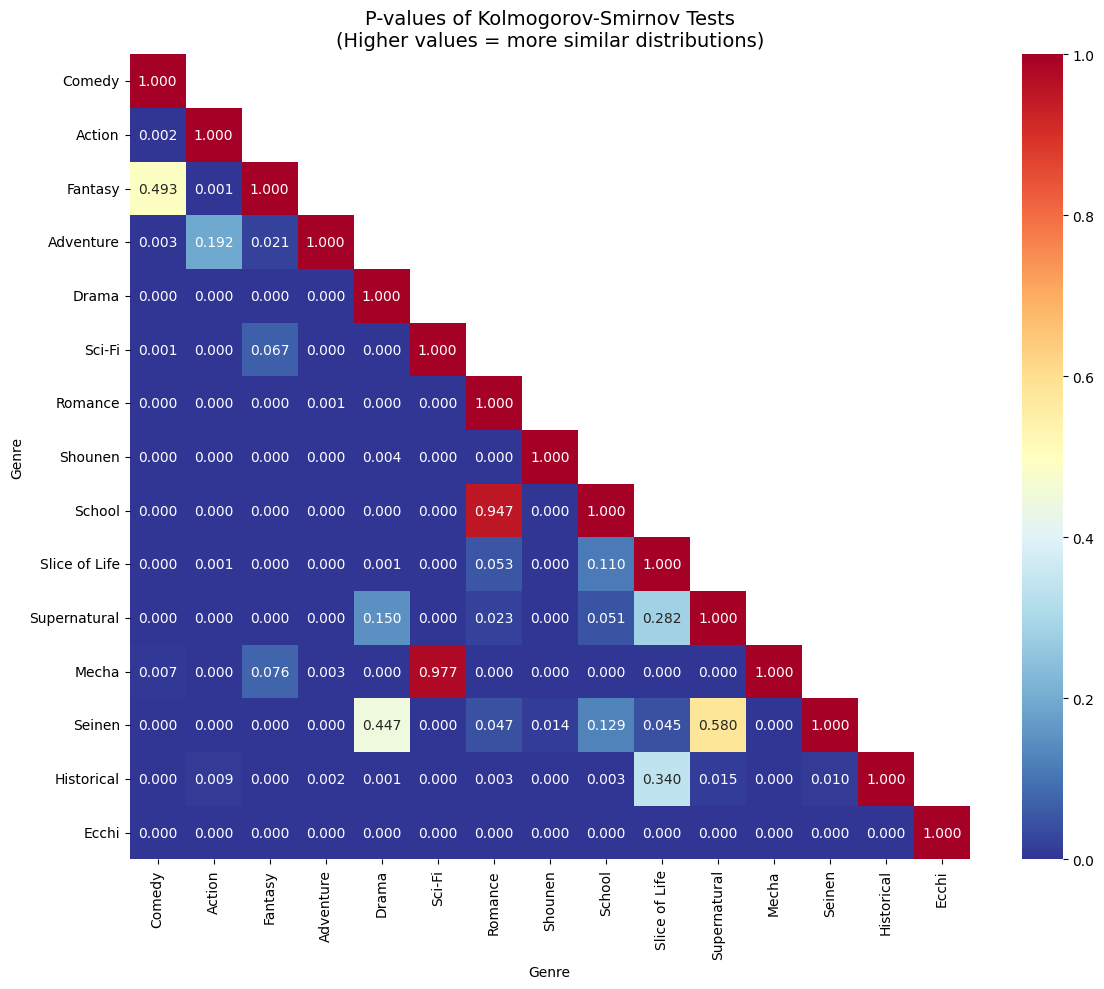


✅ Analysis complete! Check the plots and results above.


In [22]:
# Cell 7: Analysis 4 - Statistical Tests and Heatmap
print("=== ANALYSIS 4: Genre Similarity Statistical Tests ===")

# Use the genre data from Cell 6
genres_list = list(popular_genres)
n_genres = len(genres_list)

# Create matrices for p-values and test statistics
p_value_matrix = np.ones((n_genres, n_genres))
test_stat_matrix = np.zeros((n_genres, n_genres))

print("Performing pairwise Kolmogorov-Smirnov tests...")
print(f"Comparing {n_genres} genres with {len(genre_df_filtered)} total genre-score pairs")

for i, genre1 in enumerate(genres_list):
    for j, genre2 in enumerate(genres_list):
        if i != j:
            scores1 = genre_df_filtered[genre_df_filtered['genre'] == genre1]['score']
            scores2 = genre_df_filtered[genre_df_filtered['genre'] == genre2]['score']
            
            # Perform KS test
            stat, p_value = ks_2samp(scores1, scores2)
            p_value_matrix[i, j] = p_value
            test_stat_matrix[i, j] = stat

# Create heatmap - only p-values
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Create mask for upper triangle (excluding diagonal)
mask = np.triu(np.ones_like(p_value_matrix, dtype=bool), k=1)

# P-value heatmap
sns.heatmap(p_value_matrix, 
            xticklabels=genres_list, 
            yticklabels=genres_list,
            annot=True, 
            fmt='.3f',
            cmap='RdYlBu_r',
            mask=mask,  # Hide upper triangle
            ax=ax)
ax.set_title('P-values of Kolmogorov-Smirnov Tests\n(Higher values = more similar distributions)', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('Genre')

plt.tight_layout()
plt.show()

print(f"\n✅ Analysis complete! Check the plots and results above.")